# Peliculas Rotten-Tomatoes
 
En nuestro proyecto vamos a utilizar el rotten_tomatoes_movies.csv
 
Objetivos:
1. Cargar datos.
2. Limpieza y preparación de datos.
3. Análisis exploratorio.
 
    3.1 Estadísticas globales
 
    3.2 Análisis por género
 
    3.3 Análisis por estudio o director
 
    3.4 Análisis temporal
   
    3.5 Análisis de retraso a streaming (si aplica)
4. Uso de NumPy para análisis auxiliar.
5. Preguntas.
6. Conclusiones.

## 1. Carga de datos

In [ ]:
# Instala pandas en el kernel actual (usa %pip para asegurar instalación en este entorno)
%pip install -q pandas
%pip install -q numpy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Aquí vamos a utilizar nuestro csv que es el rotten_tomatoes_movies.csv
df = pd.read_csv("rotten_tomatoes_movies.csv")

# Mostramos las primeras filas de nuestro csv
display(df.head())

# Como nuestro csv mayoritariamente tiene texto utilizaremos el .info en vez del .describe que es para numéricas
df.info()

# Estadísticas básicas (incluyendo texto)
display(df.describe(include='all'))

#CONVERSION DE TIPOS
print("Tipos ANTES:")
print(df.dtypes)

# Conversión in_theaters_date y on_streaming_date a datetime
df['in_theaters_date'] = pd.to_datetime(df['in_theaters_date'], errors='coerce', dayfirst=True)
df['on_streaming_date'] = pd.to_datetime(df['on_streaming_date'], errors='coerce', dayfirst=True)

# Conversión in_theaters_date y on_streaming_date a datetime
df['runtime_in_minutes'] = pd.to_numeric(df['runtime_in_minutes'], errors='coerce')
df['tomatometer_rating'] = pd.to_numeric(df['tomatometer_rating'], errors='coerce')
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['tomatometer_count'] = pd.to_numeric(df['tomatometer_count'], errors='coerce')
df['audience_count'] = pd.to_numeric(df['audience_count'], errors='coerce')



print("\nTipos DESPUÉS:")
print(df.dtypes)

display(df.head())


## 2. Limpieza y preparación de datos

In [3]:
# Detectar filas duplicadas completas
duplicados = df[df.duplicated()]
print("Filas duplicadas detectadas:")
display(duplicados)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

print("Tamaño tras eliminar duplicados:", df.shape)

# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())

# Normalizar el campo genre:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Acción  -> Acción, 'Ciencia Ficcion' -> 'CienciaFiccion')
df['genre'] = (
    df['genre']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['genre']].head(10))
 
# Buscar todas las filas que contienen "Horror"
horror_rows = df[df['genre'].str.contains('Horror', case=False, na=False)]
print("Filas con Horror:")
display(horror_rows)

# Aquí vamos a hacer distintas columnas derivadas que nos serviran para hacer distintas busquedas

    # Empezaremos mostrando la diferencia de días entre el estreno en cines y el estreno en teatros.
df['days_to_streaming'] = df['on_streaming_date'] - df['in_theaters_date'] 
print("[Días de diferencia en el estreno")
display(df[['movie_title', 'days_to_streaming']])

#Ahora vamos a contar el total de votos, sumando los votos del tomatometer y los de la audiencia 
df['total_votes'] = df['tomatometer_count'] + df['audience_count']

print("Cantidad de votos")
display(df[['movie_title', 'total_votes']])

#Vamos a hacer una lista de las diferentes películas certificadas
certificado = df['tomatometer_status'] == "Certified Fresh"
print("Peliulas certificadas")
display(df[certificado][['movie_title','studio_name', 'audience_rating']])

Filas duplicadas detectadas:


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,days_to_streaming,total_votes


Tamaño tras eliminar duplicados: (16637, 19)
Valores nulos por columna:
movie_title              0
movie_info              24
critics_consensus     8328
rating                   0
genre                    0
directors              114
writers               1349
cast                   284
in_theaters_date      9747
on_streaming_date        2
runtime_in_minutes     155
studio_name            415
tomatometer_status       0
tomatometer_rating       0
tomatometer_count        0
audience_rating        252
audience_count         252
days_to_streaming     9747
total_votes            252
dtype: int64
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'days_to_streaming', 'total_votes']
Columnas actuales del DataFrame:
['movie_title', 'm

,genre
0,"Action&Adventure,Comedy,Drama,Sciencefiction&F..."
2,Comedy
3,"Comedy,Romance"
4,"Classics,Drama"
5,"Action&Adventure,Drama,Kids&Family"
6,"Action&Adventure,Classics,Drama"
7,"Action&Adventure,Classics,Mystery&Suspense"
8,"Classics,Drama,Western"
9,"Comedy,Drama,Romance"
10,"Classics,Drama"


Filas con Horror:


...

,movie_title,days_to_streaming
0,Percy Jackson & the Olympians: The Lightning T...,-156 days
2,Please Give,NaT
3,10,6684 days
4,12 Angry Men (Twelve Angry Men),NaT
5,"20,000 Leagues Under The Sea",18036 days
...,...,...
16634,Zoot Suit,8141 days
16635,Zootopia,65 days
16636,Zorba the Greek,NaT
16637,Zulu,NaT


Cantidad de votos


,movie_title,total_votes
0,Percy Jackson & the Olympians: The Lightning T...,254431.0
2,Please Give,11707.0
3,10,14692.0
4,12 Angry Men (Twelve Angry Men),105051.0
5,"20,000 Leagues Under The Sea",68887.0
...,...,...
16634,Zoot Suit,1201.0
16635,Zootopia,101225.0
16636,Zorba the Greek,7135.0
16637,Zulu,30191.0


Peliulas certificadas


,movie_title,studio_name,audience_rating
2,Please Give,Sony Pictures Classics,64.0
4,12 Angry Men (Twelve Angry Men),Criterion Collection,97.0
7,The 39 Steps,Gaumont British Distributors,86.0
21,The Adventures of Robin Hood,Warner Bros.,89.0
38,The Matador,The Weinstein Company,65.0
...,...,...,...
16614,Zero Days,Jigsaw Productions,75.0
16616,Zero Motivation,Zeitgeist Films,77.0
16623,Zodiac,Paramount Pictures,77.0
16627,Zombieland,Sony/Columbia Pictures,86.0


## 3. Analisis exploratorio

{'runtime_in_minutes': np.float64(2000.0),
 'tomatometer_rating': np.int64(100),
 'audience_rating': np.float64(100.0),
 'tomatometer_count': np.int64(497),
 'audience_count': np.float64(35797635.0)}

{'runtime_in_minutes': np.float64(1.0),
 'tomatometer_rating': np.int64(0),
 'audience_rating': np.float64(0.0),
 'tomatometer_count': np.int64(5),
 'audience_count': np.float64(5.0)}

,Frecuencia
audience_rating,
"[0.0, 20.0)",377
"[20.0, 40.0)",2637
"[40.0, 60.0)",4418
"[60.0, 80.0)",5441
"[80.0, 100.1)",3512


,Frecuencia2
tomatometer_rating,
"[0.0, 20.0)",1897
"[20.0, 40.0)",2457
"[40.0, 60.0)",2879
"[60.0, 80.0)",3634
"[80.0, 100.1)",5770


<Axes: xlabel='tomatometer_rating'>

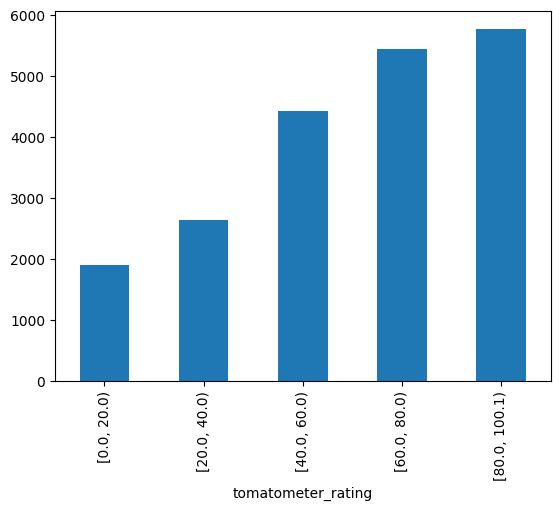

In [ ]:
#tutorial de youtube que he seguido https://www.youtube.com/watch?v=r1ZVISvsaqU
 
#Miro los maxioss
maximos = {
    'runtime_in_minutes': df['runtime_in_minutes'].max(),
    'tomatometer_rating': df['tomatometer_rating'].max(),
    'audience_rating': df['audience_rating'].max(),
    'tomatometer_count': df['tomatometer_count'].max(),
    'audience_count': df['audience_count'].max()
}
display(maximos)
#Miro los minimos
minimos = {
    'runtime_in_minutes': df['runtime_in_minutes'].min(),
    'tomatometer_rating': df['tomatometer_rating'].min(),
    'audience_rating': df['audience_rating'].min(),
    'tomatometer_count': df['tomatometer_count'].min(),
    'audience_count': df['audience_count'].min()
}
display(minimos)
 
#de momento pongo que haya 5 intervalos
intervalos = 5
 
#calcula los intervalos de cada atributo
anchos_intervalos = {
    key: (maximos[key] - minimos[key]) / intervalos
    for key in maximos.keys()
}
anchos_intervalos
 
#Hago la tabla de pfrequencias de audience_rating
tabla_frecuencias = pd.cut(df['audience_rating'],
                          bins=intervalos,
                          right=False).value_counts().sort_index()
display(tabla_frecuencias.to_frame(name='Frecuencia'))
 
tabla_frecuencias.plot(kind='bar')


## 3.1 Estadisticas globales

In [6]:

numericas = [
    'runtime_in_minutes',
    'tomatometer_rating',
    'audience_rating',
    'tomatometer_count',
    'audience_count',
    'days_to_streaming'
]


estadisticos = df[numericas].agg(['mean', 'median', 'std', 'min', 'max'])
print("ESTADÍSTICOS DE VARIABLES NUMÉRICAS:")
print(estadisticos)


cantidad_peliculas = len(df)

# Cantidad de estudios distintos
cantidad_estudios = df['studio_name'].nunique()

# Cantidad de directores distintos
cantidad_directores = df['directors'].nunique()

# Convertir todos los actores en una lista individual de nombres
lista_actores = (
    df['cast']
    .dropna()  # quitar vacíos
    .str.split(',')  # separar por coma
    .explode()  # convertir listas en filas
    .str.strip()  # quitar espacios
)

# Contar actores distintos
actores_unicos = lista_actores.nunique()


print("\nCANTIDADES:")
print("Películas:", cantidad_peliculas)
print("Estudios distintos:", cantidad_estudios)
print("Directores distintos:", cantidad_directores)
print("Actores distintos:", actores_unicos)

ESTADÍSTICOS DE VARIABLES NUMÉRICAS:
        runtime_in_minutes  tomatometer_rating  audience_rating  \
mean            102.392367           60.464146         60.47159   
median           99.000000           66.000000         62.00000   
std              25.028519           28.586446         20.46276   
min               1.000000            0.000000          0.00000   
max            2000.000000          100.000000        100.00000   

        tomatometer_count  audience_count            days_to_streaming  
mean            56.609966    1.524890e+05 3710 days 05:17:28.127721344  
median          28.000000    4.877000e+03            341 days 00:00:00  
std             66.384769    1.817791e+06 6368 days 11:23:45.349425344  
min              5.000000    5.000000e+00         -6364 days +00:00:00  
max            497.000000    3.579764e+07          33506 days 00:00:00  

CANTIDADES:
Películas: 16637
Estudios distintos: 2886
Directores distintos: 8314
Actores distintos: 198667


## 3.2 Análisis por género

In [10]:


df_generos = (
    df.assign(genre=df['genre'].str.split(','))
      .explode('genre')
)

# Quitar espacios en blanco
df_generos['genre'] = df_generos['genre'].str.strip()
analisis_genero = (
    df_generos.groupby("genre")
        .agg(
            numero_peliculas=("movie_title", "count"),
            duracion_media=("runtime_in_minutes", "mean"),
            rating_criticos_medio=("tomatometer_rating", "mean"),
            rating_audiencia_medio=("audience_rating", "mean")
        )
)

# Ordenar por rating medio de audiencia (de mayor a menor)
analisis_genero_ordenado = analisis_genero.sort_values(
    by="rating_audiencia_medio",
    ascending=False
)

print(analisis_genero_ordenado)



                        numero_peliculas  duracion_media  \
genre                                                      
Sports&Fitness                       175       98.725714   
Documentary                         1916       92.543786   
Anime&Manga                           15      100.400000   
SpecialInterest                     1219       93.445813   
Classics                            1578      108.821926   
Musical&PerformingArts               976      102.685185   
Faith&Spirituality                    78      106.051282   
ArtHouse&International              2407      105.564711   
Television                           258      101.445736   
Animation                            565       86.136445   
Western                              283      110.498221   
Nan                                   17       89.647059   
Romance                             1807      108.046771   
Drama                               9005      106.865780   
Gay&Lesbian                           68

## 3.3 Análisis por estudio o director

In [13]:
analisis_estudio = (
    df.groupby("studio_name")
      .agg(
          numero_peliculas=("movie_title", "count"),
          rating_criticos_medio=("tomatometer_rating", "mean"),
          rating_audiencia_medio=("audience_rating", "mean"),
          duracion_media=("runtime_in_minutes", "mean")
      )
      .sort_values(by="rating_audiencia_medio", ascending=False)
)

print("ANÁLISIS POR ESTUDIO:")
print(analisis_estudio)
df_directores = (
    df.assign(directors=df['directors'].str.split(','))
      .explode('directors')
)

# Quitar espacios en blanco
df_directores['directors'] = df_directores['directors'].str.strip()
analisis_director = (
    df_directores.groupby("directors")
      .agg(
          numero_peliculas=("movie_title", "count"),
          rating_criticos_medio=("tomatometer_rating", "mean"),
          rating_audiencia_medio=("audience_rating", "mean"),
          duracion_media=("runtime_in_minutes", "mean")
      )
      .sort_values(by="rating_audiencia_medio", ascending=False)
)

print("ANÁLISIS POR DIRECTOR:")
print(analisis_director)

mejor_estudio_audiencia = analisis_estudio.nlargest(1, "rating_audiencia_medio")
print("Mejor estudio según audiencia:")
print(mejor_estudio_audiencia)
mejor_estudio_criticos = analisis_estudio.nlargest(1, "rating_criticos_medio")
print("Mejor estudio según críticos:")
print(mejor_estudio_criticos)
mejor_director_audiencia = analisis_director.nlargest(1, "rating_audiencia_medio")
print("Mejor director según audiencia:")
print(mejor_director_audiencia)
mejor_director_criticos = analisis_director.nlargest(1, "rating_criticos_medio")
print("Mejor director según críticos:")
print(mejor_director_criticos)



ANÁLISIS POR ESTUDIO:
                                 numero_peliculas  rating_criticos_medio  \
studio_name                                                                
Milestone Films                                 1                   89.0   
NEON/Hulu                                       1                   83.0   
HBO Sports                                      1                  100.0   
Big Mouth Productions                           1                  100.0   
Shadowbox Films                                 1                   88.0   
...                                           ...                    ...   
Warner Bros. Home Entertainment                 1                   44.0   
Warner Brothers Classics                        1                   90.0   
Well Go USA Inc.                                1                   71.0   
WigglyWorld Studios                             1                   40.0   
Zentropa Entertainments                         1                 

## 3.4 Analisis temporal

ANÁLISIS TEMPORAL:
        numero_peliculas  rating_audiencia_medio
year                                            
1914.0                 1               69.000000
1915.0                 2               56.000000
1916.0                 1               77.000000
1919.0                 1               52.000000
1920.0                 4               75.750000
...                  ...                     ...
2015.0               238               54.067797
2016.0               260               53.439689
2017.0               234               56.819383
2018.0               236               57.995614
2019.0               168               62.579618

[103 rows x 2 columns]


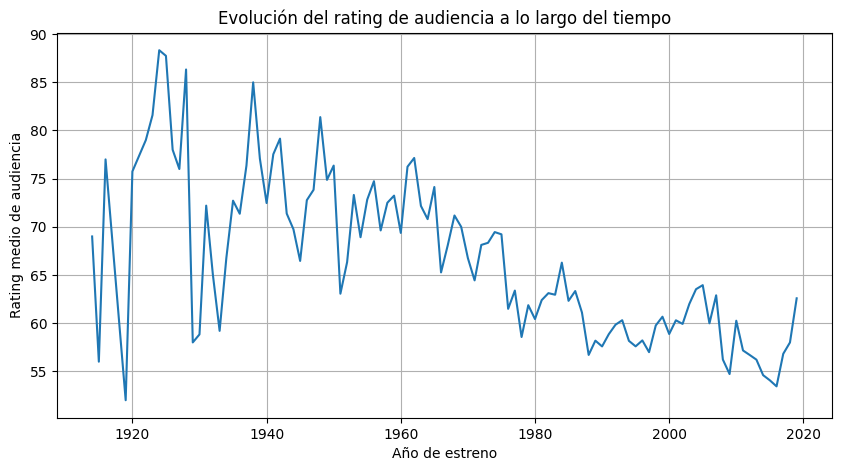

In [ ]:

df['in_theaters_date'] = pd.to_datetime(df['in_theaters_date'], errors='coerce')

# Extraer año
df['year'] = df['in_theaters_date'].dt.year
analisis_temporal = (
    df.groupby("year")
      .agg(
          numero_peliculas=("movie_title", "count"),
          rating_audiencia_medio=("audience_rating", "mean")
      )
      .sort_index()  # ordenar por año
)

print("ANÁLISIS TEMPORAL:")
print(analisis_temporal)


plt.figure(figsize=(10,5))
plt.plot(analisis_temporal.index, analisis_temporal["rating_audiencia_medio"])
plt.xlabel("Año de estreno")
plt.ylabel("Rating medio de audiencia")
plt.title("Evolución del rating de audiencia a lo largo del tiempo")
plt.grid(True)
plt.show()


## 3.5 Análisis de retraso a streaming (si aplica)

===== ESTADÍSTICOS DE days_to_streaming_num (en días) =====
count                            16637
mean     2008-08-13 14:35:03.696580352
min                1935-06-06 00:00:00
25%                2003-01-28 00:00:00
50%                2008-04-08 00:00:00
75%                2014-05-12 00:00:00
max                2019-11-01 00:00:00
Name: days_to_streaming_num, dtype: object 



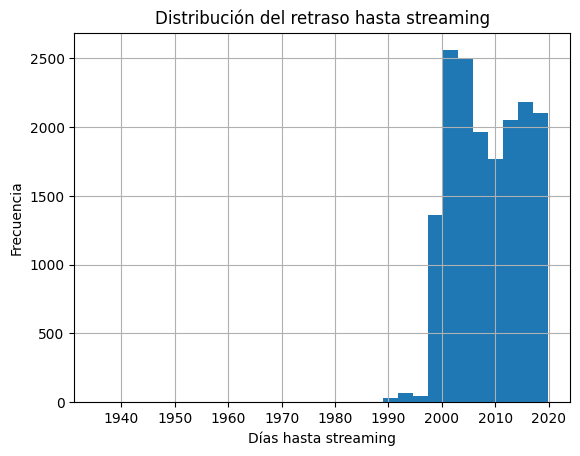

DTypePromotionError: The DType <class 'numpy.dtypes.Float64DType'> could not be promoted by <class 'numpy.dtypes.DateTime64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Float64DType'>)

In [5]:

if np.issubdtype(df["days_to_streaming"].dtype, np.timedelta64):
    df["days_to_streaming_num"] = df["days_to_streaming"] / np.timedelta64(1, "D")
    # Alternativa equivalente:
    # df["days_to_streaming_num"] = df["days_to_streaming"].dt.days
else:
    # Si ya es numérica, simplemente la copiamos
    df["days_to_streaming_num"] = df["days_to_streaming"]

# 2) Estadísticos descriptivos del retraso hasta streaming
print("===== ESTADÍSTICOS DE days_to_streaming_num (en días) =====")
print(df["days_to_streaming_num"].describe(), "\n")

# 3) Histograma de la distribución del retraso
plt.figure()
plt.hist(df["days_to_streaming_num"].dropna(), bins=30)
plt.xlabel("Días hasta streaming")
plt.ylabel("Frecuencia")
plt.title("Distribución del retraso hasta streaming")
plt.grid(True)
plt.show()

# 4) Correlación entre retraso y ratings

# ---- Con audience_rating ----
mask_aud = df["days_to_streaming_num"].notna() & df["audience_rating"].notna()

corr_audience = np.corrcoef(
    df.loc[mask_aud, "days_to_streaming_num"],
    df.loc[mask_aud, "audience_rating"]
)[0, 1]

print("Correlación entre days_to_streaming_num y audience_rating:", corr_audience)

# ---- Con tomatometer_rating ----
mask_crit = df["days_to_streaming_num"].notna() & df["tomatometer_rating"].notna()

corr_critics = np.corrcoef(
    df.loc[mask_crit, "days_to_streaming_num"],
    df.loc[mask_crit, "tomatometer_rating"]
)[0, 1]

print("Correlación entre days_to_streaming_num y tomatometer_rating:", corr_critics, "\n")

# 5) Gráficos de dispersión (opcional pero recomendable)

# Retraso vs rating de audiencia
plt.figure()
plt.scatter(df["days_to_streaming_num"], df["audience_rating"])
plt.xlabel("Días hasta streaming")
plt.ylabel("Audience rating")
plt.title("Retraso hasta streaming vs Rating de audiencia")
plt.grid(True)
plt.show()

# Retraso vs rating de críticos
plt.figure()
plt.scatter(df["days_to_streaming_num"], df["tomatometer_rating"])
plt.xlabel("Días hasta streaming")
plt.ylabel("Tomatometer rating")
plt.title("Retraso hasta streaming vs Rating de críticos")
plt.grid(True)
plt.show()


## 4. Uso de NumPy para análisis auxiliar

## 5. Preguntes

## 6. Conclusiones

In [ ]:
# Conteo de valores nulos por columna
print("Valores nulos por columna:")
print(df.isna().sum())

# Rellenar NaN en columnas numéricas clave con valores por defecto
df.fillna({'screen_time(min)': 0, 'notifications': 0}, inplace=True)

# Eliminar filas que no tengan app o tiempo de pantalla (esenciales para análisis)
df.dropna(subset=['critics_consensus'], inplace=True)

print('\nDespués de limpieza de NaN:')
print(df.isna().sum())

display(df.head())


## 5. Eliminación de columnas vacías

In [ ]:
# Eliminamos columnas que estén completamente vacías
print("Columnas actuales del DataFrame:")
print(df.columns.tolist())
df.dropna(axis=1, how='all', inplace=True)

print("Columnas actuales del DataFrame:")
print(df.columns.tolist())


Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count', 'columna_vacia']
Columnas actuales del DataFrame:
['movie_title', 'movie_info', 'critics_consensus', 'rating', 'genre', 'directors', 'writers', 'cast', 'in_theaters_date', 'on_streaming_date', 'runtime_in_minutes', 'studio_name', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_rating', 'audience_count']


## 6. Limpieza y normalización de texto (`.str` en Pandas)

In [ ]:
# Normalizar nombres de apps:
# - quitar espacios en blanco
# - poner la primera letra en mayúscula de cada palabra
# - eliminar espacios internos (Instagram  -> Instagram, 'YouTube Music' -> 'Youtubemusic')
df['app_name'] = (
    df['app_name']
      .astype(str)
      .str.strip()
      .str.title()
      .str.replace(' ', '', regex=False)
)
 
display(df[['app_name']].head(10))
 
# Buscar todas las filas que contienen "Youtube"
youtube_rows = df[df['app_name'].str.contains('Youtube', case=False, na=False)]
print("Filas con Youtube:")
display(youtube_rows)

## 7. Métodos extra de cadena (`str.len`, `str.startswith`, etc.)

In [ ]:
# Longitud del nombre de la app
df['app_name_len'] = df['app_name'].str.len()

# Apps que empiezan por 'Y'
apps_y = df[df['app_name'].str.startswith('Y', na=False)]

print("Apps que empiezan por 'Y':")
display(apps_y[['app_name', 'app_name_len']].drop_duplicates())

display(df[['app_name', 'app_name_len']].head())


## 8. Detección de tipos mezclados en columnas

In [ ]:
print("Tipos actuales:")
print(df.dtypes)

print("\nTipo real de cada celda en las primeras filas:")
display(df.applymap(type).head())

# Convertir automáticamente al tipo más adecuado (opcional)
df = df.convert_dtypes()

print("\nTipos tras convert_dtypes():")
print(df.dtypes)


## 9. Guardar el dataset limpio

In [ ]:
df.to_csv('screentime_analysis_clean.csv', index=False)
print('Archivo screentime_analysis_clean.csv guardado correctamente.')

Archivo screentime_analysis_clean.csv guardado correctamente.


## 10. Mini análisis final por aplicación

In [ ]:
# ¿Qué apps tienen más tiempo medio de pantalla?
screen_time_media = (
    df.groupby('app_name')['screen_time(min)']
      .mean()
      .sort_values(ascending=False)
)

print("Tiempo medio de pantalla (min) por app:")
display(screen_time_media)

# ¿Qué apps generan más notificaciones?
notif_media = (
    df.groupby('app_name')['notifications']
      .mean()
      .sort_values(ascending=False)
)

print("Notificaciones medias por app:")
display(notif_media)
